Name: Pritesh Das (ID: 1002333230)

Subject: DASC 5305 Data Visualization

Submission Type: Home Work 2


**1. Data Preparation**

In [38]:
pip install geodatasets

Imports

In [39]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from geodatasets import get_path


plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)


a) Load the dataset using pandas.

In [40]:
file_path = "/content/region_2.csv"


df = pd.read_csv(file_path, low_memory=False)

print("Shape of raw data:", df.shape)
print("\nPreview of raw data:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())


Shape of raw data: (10386, 135)

Preview of raw data:
        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  1.970000e+11   1970       7     2        NaN         0        NaN       58   
1  1.970010e+11   1970       1    20        NaN         0        NaN       83   
2  1.970030e+11   1970       3     6        NaN         1   3/8/1970       83   
3  1.970030e+11   1970       3    24        NaN         1  3/26/1970       58   
4  1.970030e+11   1970       3    31        NaN         1   4/5/1970       83   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1           Guatemala       2  ...      NaN    NaN    NaN     NaN      PGIS   
2           Guatemala       2  ...      NaN    NaN    NaN     NaN      PGIS   
3  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
4           Guatemala       2  ...      NaN    NaN    NaN     Na

b) Clean the data by removing rows with missing latitude or longitude.

In [41]:

cols_needed = [
    "eventid",
    "iyear",
    "imonth",
    "iday",
    "country_txt",
    "region_txt",
    "city",
    "latitude",
    "longitude",
    "attacktype1_txt",
    "nkill",
    "nwound",
]


gdf = df[cols_needed].copy()


before = gdf.shape[0]
gdf = gdf.dropna(subset=["latitude", "longitude"])
after = gdf.shape[0]

print(f"Rows before dropping missing lat/long: {before}")
print(f"Rows after dropping missing lat/long:  {after}")


Rows before dropping missing lat/long: 10386
Rows after dropping missing lat/long:  9386


c) Create a GeoDataFrame using GeoPandas.

d) Display the first few rows of the GeoDataFrame

In [42]:
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(gdf["longitude"], gdf["latitude"])]

# assuming WGS84 (EPSG:4326) coordinates
gdf = gpd.GeoDataFrame(gdf, geometry=geometry, crs="EPSG:4326")


print("\nFirst 5 rows of GeoDataFrame:")
print(gdf.head())



First 5 rows of GeoDataFrame:
        eventid  iyear  imonth  iday         country_txt  \
0  1.970000e+11   1970       7     2  Dominican Republic   
1  1.970010e+11   1970       1    20           Guatemala   
2  1.970030e+11   1970       3     6           Guatemala   
3  1.970030e+11   1970       3    24  Dominican Republic   
4  1.970030e+11   1970       3    31           Guatemala   

                    region_txt            city   latitude  longitude  \
0  Central America & Caribbean   Santo Domingo  18.456792 -69.951164   
1  Central America & Caribbean  Guatemala City  14.622869 -90.529068   
2  Central America & Caribbean  Guatemala City  14.622869 -90.529068   
3  Central America & Caribbean   Santo Domingo  18.456792 -69.951164   
4  Central America & Caribbean  Guatemala City  14.622869 -90.529068   

               attacktype1_txt  nkill  nwound                    geometry  
0                Assassination    1.0     0.0  POINT (-69.95116 18.45679)  
1                Assass

 e) Show summary statistics of numerical columns

 f) Create a simple plot of the data using GeoPandas' built-in plotting functionality


Summary statistics (numeric columns):
             iyear       imonth         iday        nkill       nwound
count  9386.000000  9386.000000  9386.000000  7326.000000  7206.000000
mean   1985.021202     6.479864    14.967292     3.365684     1.135165
std       5.687275     3.467924     8.504591    10.776091     4.461857
min    1970.000000     0.000000     0.000000     0.000000     0.000000
25%    1981.000000     3.000000     8.000000     0.000000     0.000000
50%    1984.000000     7.000000    15.000000     0.000000     0.000000
75%    1988.000000    10.000000    22.000000     2.000000     0.000000
max    2020.000000    12.000000    31.000000   300.000000   130.000000


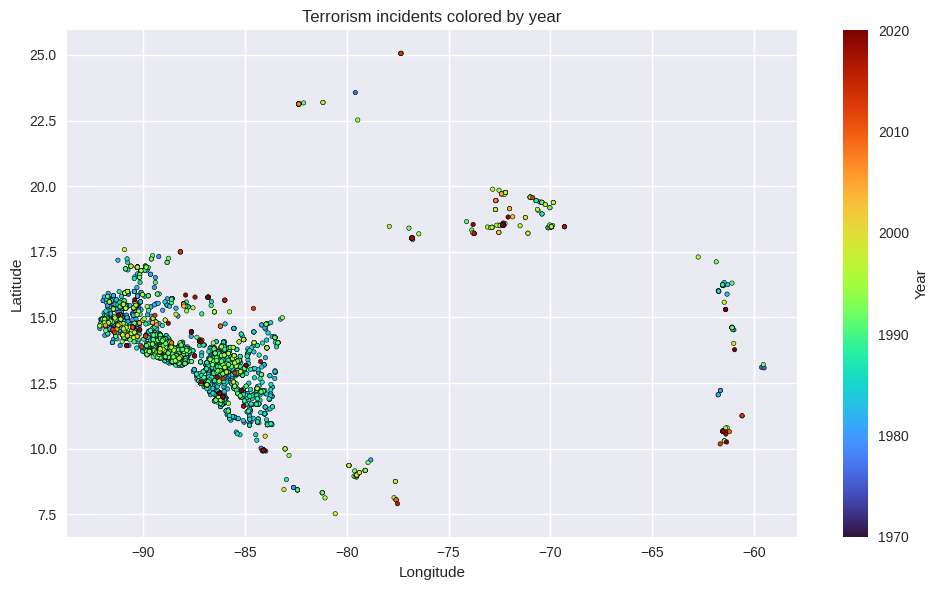

In [43]:
print("\nSummary statistics (numeric columns):")
print(gdf[["iyear", "imonth", "iday", "nkill", "nwound"]].describe())


x = gdf["longitude"]
y = gdf["latitude"]

plt.figure(figsize=(10, 6))


scatter = plt.scatter(
    x,
    y,
    c=gdf["iyear"],
    cmap="turbo",
    s=10,
    facecolors="none",
    edgecolors="k",
    linewidths=0.4
)

plt.title("Terrorism incidents colored by year")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cbar = plt.colorbar(scatter)
cbar.set_label("Year")
plt.tight_layout()
plt.show()


**2. Geospatial Visualizations**

a) Create a base map with markers for each incident using Folium.

In [44]:

center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

base_map = folium.Map(location=[center_lat, center_lon],
                      zoom_start=5, tiles="CartoDB positron")


for _, row in gdf.iterrows():    # marker for each incident
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['city']}, {row['country_txt']} ({row['iyear']})"
    ).add_to(base_map)


base_map.save("terrorism_base_map.html")
print("Saved: terrorism_base_map.html")


Saved: terrorism_base_map.html


b) Generate a choropleth map showing the number of incidents per country.

In [45]:

country_counts = df['country_txt'].value_counts().reset_index()
country_counts.columns = ['country_txt', 'incident_count']



In [46]:
import os
import requests
import json

# Aggregating counts per country
country_counts = (
    gdf.groupby("country_txt")
       .size()
       .reset_index(name="incident_count")
)


country_counts = country_counts.sort_values(
    "incident_count", ascending=False
).reset_index(drop=True)
country_counts["rank"] = country_counts.index + 1

print("\nTop 10 countries by incident count (for sanity check):")
print(country_counts.head(10)[["rank", "country_txt", "incident_count"]])


geojson_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
geojson_path = "world_countries.json"

if not os.path.exists(geojson_path):
    resp = requests.get(geojson_url)
    resp.raise_for_status()
    with open(geojson_path, "w", encoding="utf-8") as f:
        f.write(resp.text)
    print("Downloaded world_countries.json")
else:
    print("Using cached world_countries.json")

with open(geojson_path, "r", encoding="utf-8") as f:
    world_geo = json.load(f)

# choropleth with Folium
center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

choropleth_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=3,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=world_geo,
    name="choropleth",
    data=country_counts,
    columns=["country_txt", "incident_count"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color="lightgray",
    legend_name="Number of incidents (region_2 subset)"
).add_to(choropleth_map)

folium.LayerControl().add_to(choropleth_map)

choropleth_map.save("terrorism_choropleth_map.html")
print("Saved: terrorism_choropleth_map.html")



Top 10 countries by incident count (for sanity check):
   rank         country_txt  incident_count
0     1         El Salvador            4846
1     2           Guatemala            1962
2     3           Nicaragua            1579
3     4            Honduras             326
4     5               Haiti             223
5     6              Panama             127
6     7  Dominican Republic              89
7     8          Costa Rica              69
8     9          Guadeloupe              39
9    10             Jamaica              34
Using cached world_countries.json
Saved: terrorism_choropleth_map.html


c) Create a heatmap of incidents.

In [47]:
heat_map = folium.Map(location=[center_lat, center_lon],
                      zoom_start=5, tiles="CartoDB dark_matter")


heat_data = gdf[["latitude", "longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius=8,
    blur=4,
    max_zoom=10
).add_to(heat_map)


heat_map.save("terrorism_heatmap.html")
print("Saved: terrorism_heatmap.html")


Saved: terrorism_heatmap.html


**3. Attack Type Analysis**

a) Analyze and visualize the top 5 attack types using a pie chart (just to humor your teacher) and also using barcharts.

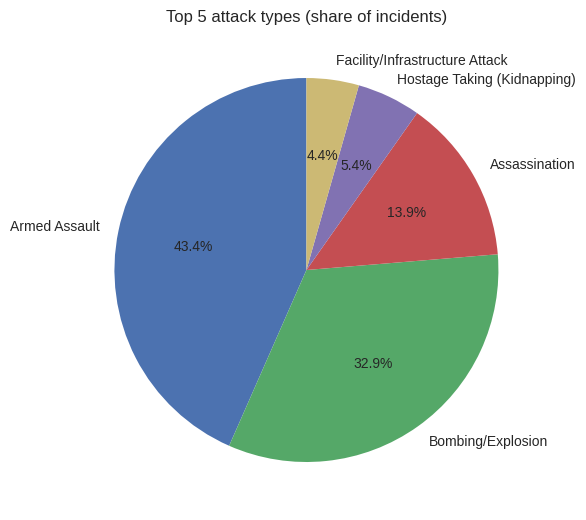

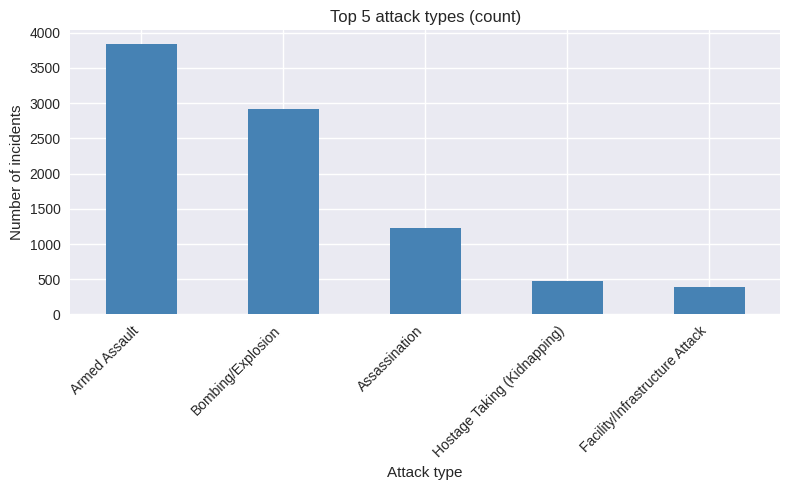

In [48]:
attack_counts = gdf["attacktype1_txt"].value_counts().sort_values(ascending=False)
top5_attack = attack_counts.head(5)

# Pie chart
plt.figure(figsize=(6, 6))
top5_attack.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Top 5 attack types (share of incidents)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Bar chart
plt.figure(figsize=(8, 5))
top5_attack.plot(kind="bar", color="steelblue")
plt.title("Top 5 attack types (count)")
plt.xlabel("Attack type")
plt.ylabel("Number of incidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

b) Print out the frequency of each attack type.

In [49]:
attack_counts = gdf["attacktype1_txt"].value_counts().sort_values(ascending=False)

print("\nAttack type frequencies:")
print(attack_counts)


top5_attack = attack_counts.head(5)


Attack type frequencies:
attacktype1_txt
Armed Assault                          3842
Bombing/Explosion                      2912
Assassination                          1232
Hostage Taking (Kidnapping)             475
Facility/Infrastructure Attack          390
Unknown                                 310
Hostage Taking (Barricade Incident)     181
Hijacking                                25
Unarmed Assault                          19
Name: count, dtype: int64


**4. Time Series Analysis**

a) Create a line plot showing the number of incidents per year.


Yearly incidents (first 10 rows):
iyear
1970      6
1971      4
1972      3
1973      6
1974     11
1975      9
1976     42
1977     23
1978    187
1979    571
dtype: int64


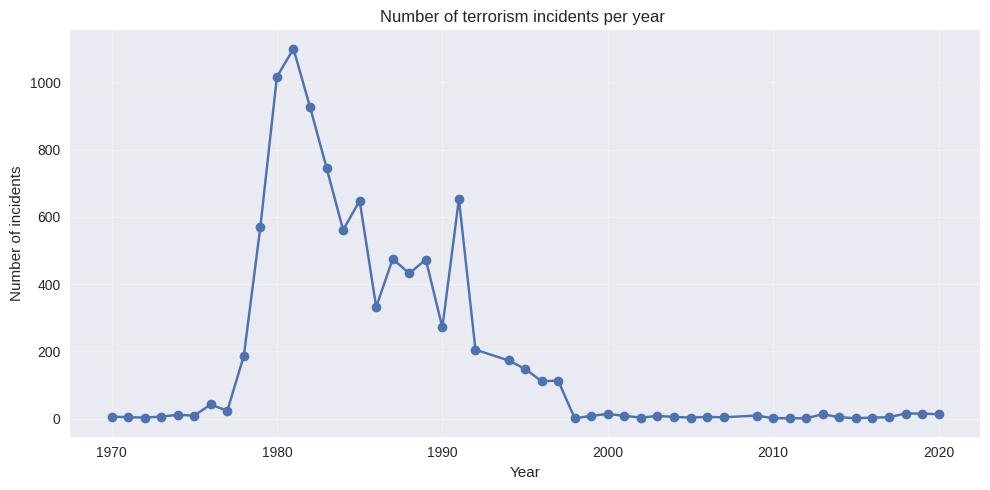

In [50]:

yearly_incidents = gdf.groupby("iyear").size()

print("\nYearly incidents (first 10 rows):")
print(yearly_incidents.head(10))

plt.figure(figsize=(10, 5))
yearly_incidents.plot(marker="o")
plt.title("Number of terrorism incidents per year ")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


b) Perform time series decomposition to analyze trend, seasonality, and residuals.

c) Plot the decomposition results.

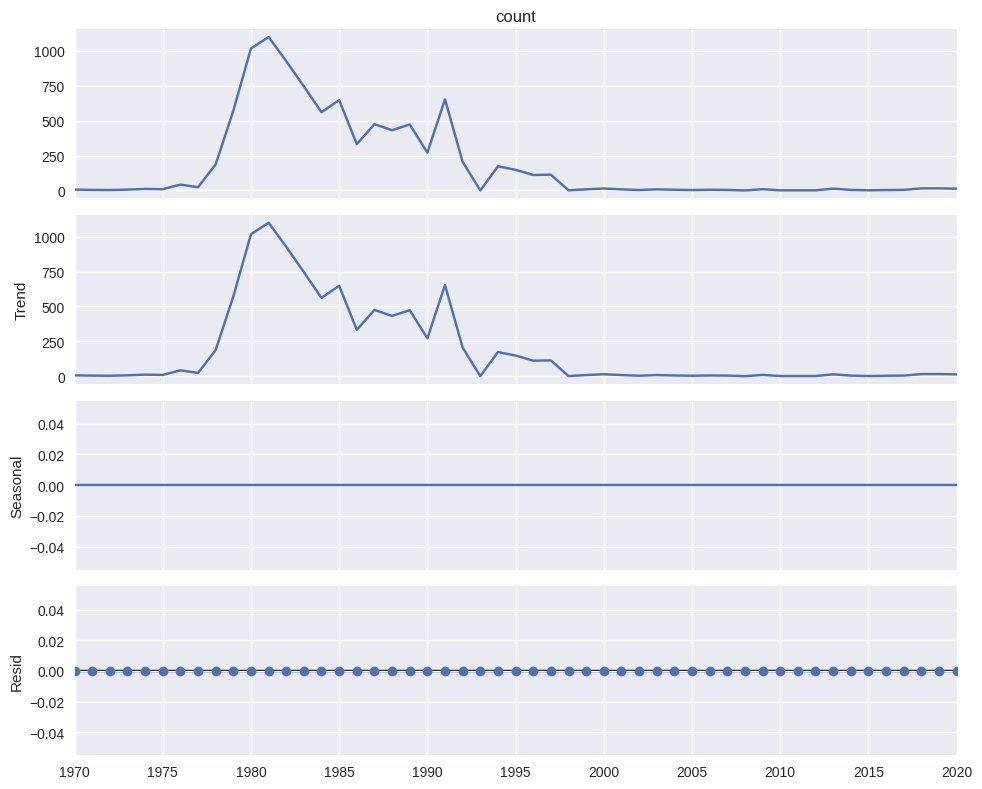

In [51]:

ts_df = yearly_incidents.reset_index()
ts_df.columns = ["year", "count"]
ts_df["date"] = pd.to_datetime(ts_df["year"].astype(str) + "-01-01")

ts_df = ts_df.set_index("date").asfreq("YS")  # yearly start frequency


ts_df["count"] = ts_df["count"].fillna(0)


decomp = seasonal_decompose(ts_df["count"], model="additive", period=1)


fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

d) Provide a brief interpretation of the decomposition results.

In [52]:
print("\n=== Basic stats of yearly incidents ===")
print(ts_df["count"].describe())





=== Basic stats of yearly incidents ===
count      51.000000
mean      184.039216
std       296.558794
min         0.000000
25%         4.000000
50%        13.000000
75%       238.000000
max      1100.000000
Name: count, dtype: float64
